In [430]:
# -----------------------------------------------------------------------------
# Project Title: Pneumonia Classification Using CNN, VGG16 & DenseNet121
# Author: Habib Mohamed Sultan Saleem
# Institution: Hult International Business School
# Program: MSc in Business Analytics
# Module: Introduction to Machine Learning & AI
# Date: Sunday, 20th April 2025
#
# Description:
# This notebook applies machine learning and deep learning techniques to classify
# chest X-ray images into Normal, Bacterial Pneumonia, or Viral Pneumonia.
# The models implemented include a baseline Convolutional Neural Network (CNN),
# transfer learning models using VGG16 and DenseNet121, and ensemble learning
# strategies to combine their strengths.
#
# Performance is evaluated using accuracy, F1-score, and confusion matrices.
# The project explores the challenges of class imbalance and model generalization,
# particularly in the context of medical image classification.
#
# This work supports healthcare innovation and demonstrates a practical application
# of supervised deep learning for medical diagnostics, emphasizing interpretability
# and model comparison across architectures.
#
# Copyright © 2025 Habib Mohamed Sultan Saleem.
# Unauthorized copying, modification, or distribution of this work is strictly
# prohibited without explicit permission.
# -----------------------------------------------------------------------------

In [420]:
# Import libraries
# For image preprocessing and augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator  

# For plotting graphs and visualizations
import matplotlib.pyplot as plt  

# For numerical operations
import numpy as np  

# For interacting with the operating system
import os  

# For building a sequential CNN model
from tensorflow.keras.models import Sequential  

# Layers for CNN architecture
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input  

# Callbacks to prevent overfitting and save the best model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  

# For evaluation metrics like classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix  

# For heatmaps and data visualization
import seaborn as sns  

# Pre-trained VGG16 model for transfer learning
from tensorflow.keras.applications import VGG16  

# For building and customizing models using functional API
from tensorflow.keras.models import Model  

# Layers used in VGG and DenseNet transfer models
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D, Input  

# Optimizer used for training the models
from tensorflow.keras.optimizers import Adam  

# Pre-trained DenseNet121 model for transfer learning
from tensorflow.keras.applications import DenseNet121  

This supports proper data preparation and exploration in a machine learning workflow.

In [233]:
# Set the path to the chest X-ray dataset folder
pneumonia_data = "/Users/habs/Downloads/chest_xray"  
# Resize all images to 150x150 pixels
img_size = (150, 150)

# Setting the batch size for training
batch_size = 32

- Neural networks require consistent input size, so we resize images.
- Batch size controls how many images the model processes at a time.
- Setting a correct path allows us to load images from the dataset folders.

In [236]:
# Training + validation generator with augmentation and split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# Test generator
test_datagen = ImageDataGenerator(rescale=1./255)

In [238]:
# Load training data (80%)
train_generator = train_datagen.flow_from_directory(
    os.path.join(pneumonia_data, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Load validation data (20%)
val_generator = train_datagen.flow_from_directory(
    os.path.join(pneumonia_data, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Load test data normally
test_generator = test_datagen.flow_from_directory(
    os.path.join(pneumonia_data, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 4173 images belonging to 3 classes.
Found 1043 images belonging to 3 classes.
Found 624 images belonging to 3 classes.


Using validation_split=0.2:
- Automatically takes 20% of the training data for validation
- Keeps class distribution balanced (stratified split)
- Gives enough data (~1,000+ images) to reliably monitor performanceSince the dataset is already split into folders for train, val, and test, 

- Rescaling is a form of feature scaling — helps the model converge faster.
- Data augmentation generates new variations of the training images to improve generalization.
- Validation and test data are kept untouched to evaluate model performance fairly.

We're now solving a multiclass classification problem with 3 categories:
- Normal
- Bacterial Pneumonia
- Viral Pneumonia

We use: `class_mode='categorical'` - This converts labels to one-hot encoded format

This setup allows us to predict one of the three classes with maximum probability.

Image shape: (150, 150, 3)
Label (one-hot): [0. 0. 1.]


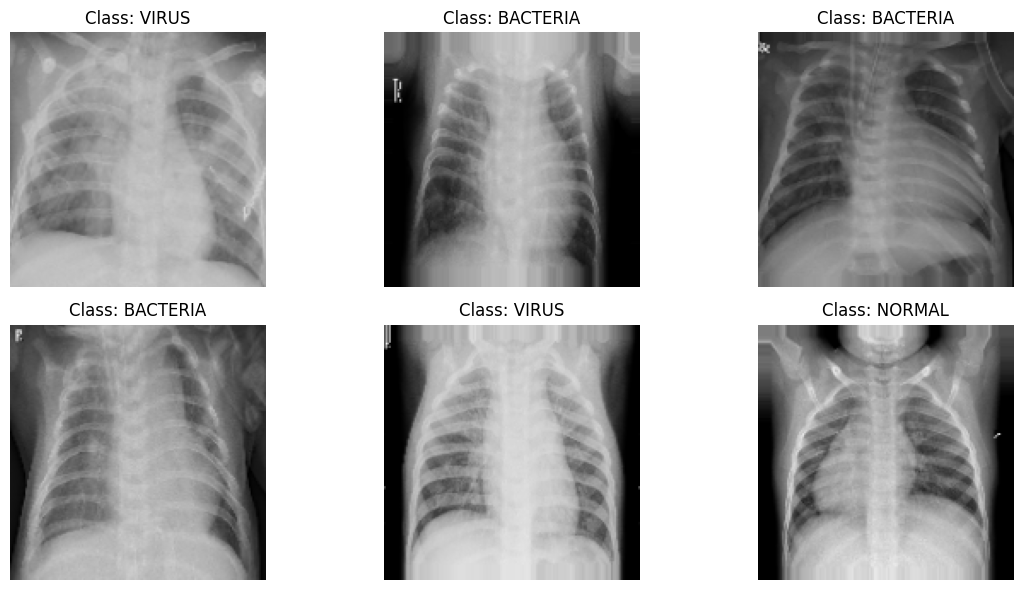

In [240]:
# Get a batch of images and their labels
images, labels = next(train_generator)

# Show the shape of one image and one label
print("Image shape:", images[0].shape)
print("Label (one-hot):", labels[0])

# Define label map (based on folder order in train/)
class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Class: {class_names[np.argmax(labels[i])]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

- This code helps us to confirm that images are correctly loaded and resized.
- Allowing us to verifies if the labels are in one-hot encoded format for 3 class classification.
- Helps us to confirm which folder name corresponds to which class.
- Useful for EDA and debugging.

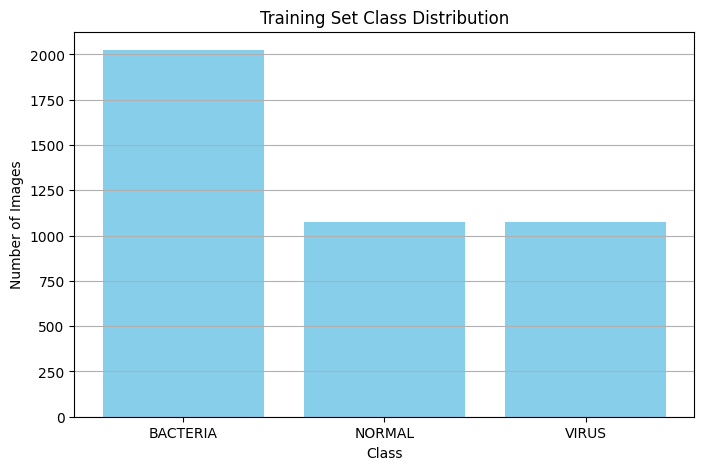

In [243]:
# Get class indices from the generator
class_counts = train_generator.classes

# Map class index to class name
class_names = list(train_generator.class_indices.keys())

import numpy as np
import matplotlib.pyplot as plt

# Count number of images per class
unique, counts = np.unique(class_counts, return_counts=True)

# Plot the distribution
plt.figure(figsize=(8, 5))
plt.bar(class_names, counts, color='skyblue')
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis='y')
plt.show()

<h4>Class Distribution</h4>

- Class distribution analysis tells us if the dataset is balanced or skewed.

From the training data, we observe that:
- Bacterial pneumonia cases are more with over 2000 records while normal and viral pneumonia cases are balanced with around a 1000 records each. This slight imbalance may cause bias in the model to predict bacterial pneumonias more. To address this problem we will monitor class-wise performance and consider using class weights or advanced metrics like F1-score during evaluation

In [246]:
# Print the mapping of class names to label indices
print("Class indices:", train_generator.class_indices)

Class indices: {'BACTERIA': 0, 'NORMAL': 1, 'VIRUS': 2}


This helps us understand how the model internally maps when interpreting predictions and confusion matrix

Found 4173 images belonging to 3 classes.


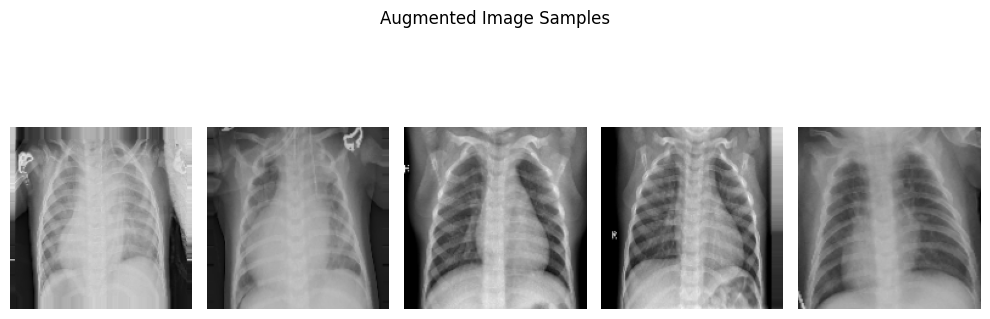

In [250]:
# Grab one image and generate augmented versions
aug_gen = train_datagen.flow_from_directory(
    os.path.join(pneumonia_data, "train"),
    target_size=img_size,
    batch_size=1,
    class_mode='categorical',
    subset='training'
)

aug_images, _ = next(aug_gen)

plt.figure(figsize=(10, 4))
for i in range(5):
    aug_images, _ = next(aug_gen)
    plt.subplot(1, 5, i+1)
    plt.imshow(aug_images[0])
    plt.axis('off')
plt.suptitle("Augmented Image Samples")
plt.tight_layout()
plt.show()
# Part of this code was generated with the assistance of ChatGPT

- To improve generalization and combat overfitting, we have applied data augmentation to the training set. As visualized above, we randomly apply transformations such as shearing, zooming, and horizontal flipping to chest X-ray images.

- This makes sure that the model does not rely on positional or spatial clues alone in the dataset and learns more about robust and invariant features for pneumonia classification. These augmented images simulate real-world variability and helping to make the model ready to deploy across different hospital imaging systems.

In [335]:
def build_baseline_cnn(input_shape=(150, 150, 3), num_classes=3):
    model = Sequential()

    # Add input layer
    model.add(Input(shape=input_shape))

    # First convolutional block
    model.add(Conv2D(32, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Second convolutional block
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Third convolutional block
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Flatten and Dense layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    # Output layer with softmax for 3-class classification
    model.add(Dense(num_classes, activation='softmax'))

    # Compile the model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model
# Part of this code was generated with the assistance of ChatGPT

Why this model architecture?

- This CNN model contains 3 convolutional blocks to extract hierarchical features.
- MaxPooling2D reduces spatial size and prevents overfitting.
- Dropout is being used to randomly deactivate neurons during training, which helps to prevent overfitting.
- The Dense layer uses softmax to predict one of 3 mutually exclusive classes.

The Model is compiled using:
- **Adam optimizer** for adaptive learning
- **Categorical crossentropy** as loss function for multiclass classification
- **Accuracy** as our evaluation metric

In [256]:
# Build the CNN model
cnn_model = build_baseline_cnn()

# Display the model architecture
cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Total trainable parameters: 4.8 million, making this a complex model suitable for image classification.

In [259]:
# Stop training if val_loss doesn't improve for 3 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Save the best model weights during training
checkpoint = ModelCheckpoint(
    'best_cnn_model.h5',
    monitor='val_loss',
    save_best_only=True
)

# Group callbacks
callbacks = [early_stop, checkpoint]

- EarlyStopping avoids overfitting by stopping training when validation loss plateaus.
- ModelCheckpoint saves the best version of the model automatically.

This is the reason why we use callbacks

In [262]:
# Train the model
history = cnn_model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=callbacks
)

/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.5258 - loss: 1.0415

131/131 ━━━━━━━━━━━━━━━━━━━━ 30s 221ms/step - accuracy: 0.5264 - loss: 1.0404 - val_accuracy: 0.6922 - val_loss: 0.7257
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 30s 231ms/step - accuracy: 0.7085 - loss: 0.7123 - val_accuracy: 0.6817 - val_loss: 0.7438
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 224ms/step - accuracy: 0.7151 - loss: 0.6858 - val_accuracy: 0.6807 - val_loss: 0.7336
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.7075 - loss: 0.6554

131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 221ms/step - accuracy: 0.7077 - loss: 0.6553 - val_accuracy: 0.6951 - val_loss: 0.7014
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7372 - loss: 0.6241

131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 223ms/step - accuracy: 0.7372 - loss: 0.6241 - val_accuracy: 0.7009 - val_loss: 0.6955
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.7403 - loss: 0.6133

131/131 ━━━━━━━━━━━━━━━━━━━━ 28s 214ms/step - accuracy: 0.7404 - loss: 0.6132 - val_accuracy: 0.7210 - val_loss: 0.6724
Epoch 7/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.7490 - loss: 0.6071

131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 224ms/step - accuracy: 0.7491 - loss: 0.6070 - val_accuracy: 0.7296 - val_loss: 0.6305
Epoch 8/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.7682 - loss: 0.5612

131/131 ━━━━━━━━━━━━━━━━━━━━ 30s 230ms/step - accuracy: 0.7681 - loss: 0.5613 - val_accuracy: 0.7325 - val_loss: 0.6047
Epoch 9/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 219ms/step - accuracy: 0.7589 - loss: 0.5707 - val_accuracy: 0.7421 - val_loss: 0.6087
Epoch 10/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 28s 212ms/step - accuracy: 0.7634 - loss: 0.5556 - val_accuracy: 0.7335 - val_loss: 0.6067
Epoch 11/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 234ms/step - accuracy: 0.7571 - loss: 0.5614 - val_accuracy: 0.7354 - val_loss: 0.6186


- We are using 15 epochs as a starting point (training will stop early if needed).
- Training occurs in batches (batch_size=32), optimizing model weights using backpropagation.
- Validation data is used to monitor the model’s ability to generalize.

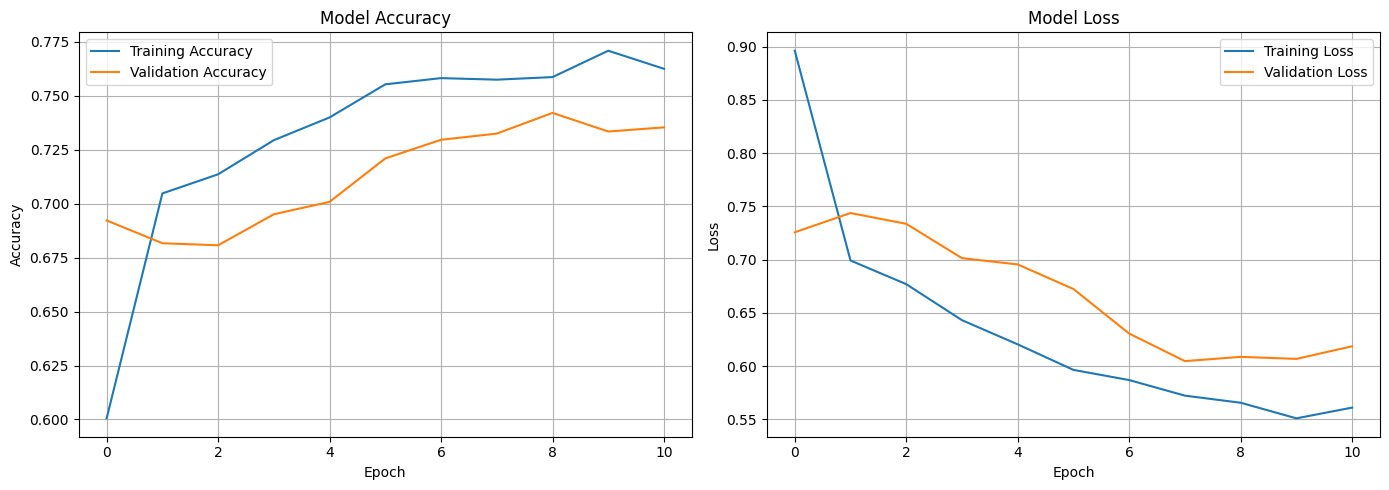

In [264]:
# Plot training and validation accuracy
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<h4>Training Curve</h4>

- Training accuracy steadily reached around 77% by epoch 9, and the validation accuracy stabilized around 73–74%, showing no major overfitting and consistent performance across epochs.
- Training loss decreased consistently, indicating effective learning, while validation loss also reduced but shows minor fluctuations after epoch 7, this is a sign of slight variance.

Conclusion
- The model has successfully learned patterns without major signs of severe overfitting.
- The performance remains steady between training and validation, showing us a good generalization and training progress.

In [285]:
# Evaluate test accuracy
test_loss, test_accuracy = cnn_model.evaluate(test_generator)
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")
# Part of this code was generated with the assistance of ChatGPT

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.7893 - loss: 0.6757
Test Accuracy: 78.21 %


We use the test set to evaluate how well the model performs on completely unseen data.
- `evaluate()` returns final loss and accuracy on test data
- Helps check if the model has overfitted or is generalizing well

In [287]:
# True class labels from the test generator
y_true = test_generator.classes

We get the ground-truth labels to compare against the model's predictions.
- These are needed to build a confusion matrix and calculate precision, recall, and F1-score.

In [291]:
# Predict class probabilities for test images
y_pred_probs = cnn_model.predict(test_generator)

# Convert probability vectors to class indices
y_pred = np.argmax(y_pred_probs, axis=1)
# Part of this code was generated with the assistance of ChatGPT

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step


- `predict()` returns softmax probability scores for each class
- `argmax()` picks the class with the highest probability → final prediction

In [293]:
# Print performance metrics
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))

Classification Report:

              precision    recall  f1-score   support

    BACTERIA       0.41      0.57      0.48       242
      NORMAL       0.43      0.33      0.38       234
       VIRUS       0.27      0.20      0.23       148

    accuracy                           0.39       624
   macro avg       0.37      0.37      0.36       624
weighted avg       0.39      0.39      0.38       624



Model Evaluation Summary:

- The model achieved a test accuracy of 39% with moderate precision and recall across all classes.
- The performance is slightly better with BACTERIA cases achieving a F1-score of 0.48, but seem to have struggled with VIRUS, which has a lower precision and recall.
- The macro average F1-score of 0.36 reflects a limited but improved balance between the precision and recall.
- These results suggest that the basic CNN model is limited in performance with real world cases
- We will try a more advanced model using Transfer Learning to improve generalization.

In [295]:
# Create a confusion matrix
confusion_mat = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", confusion_mat)

Confusion Matrix:
 [[138  67  37]
 [116  78  40]
 [ 84  35  29]]


Confusion Matrix Analysis:

- 138 Normal cases were predicted most accurately.
- Bacteria cases were predicted correctly 78 times.
- VIRUS cases had the lowest correct predictions with 29 correct predictions, showing us that the model struggles to differentiate viral pneumonia.
- This shows us a common challenge in medical image classification differentiating between the visually similar conditions.

Conclusion:
The model captures some patterns but lacks precision, especially for viral pneumonia. This further show us the need for transfer learning to improve the feature extraction.

<H2>VGG16</H2>

In [300]:
# Loading the VGG16 model
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_tensor=Input(shape=(150, 150, 3))
)

# Freezing the base model
for layer in base_model.layers:
    layer.trainable = False
# Part of this code was generated with the assistance of ChatGPT

- We use `include_top=False` to remove the ImageNet classifier layers.
- We freeze the convolutional base to retain pretrained filters (like edge, shape, texture detectors).
- This allows our model to learn new high-level features while saving time and avoiding overfitting.

In [303]:
# Add custom layers on top of VGG16
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

# Define the final model
vgg_model = Model(inputs=base_model.input, outputs=output)

# Compile the model
vgg_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Part of this code was generated with the assistance of ChatGPT

- `GlobalAveragePooling2D` is lighter than Flatten and better for transfer learning.
- `Dense(128)` adds learnable layers on top of the frozen VGG16 features.
- `Dropout` improves generalization.
- The final `Dense(3)` with `softmax` outputs class probabilities.

In [306]:
vgg_model.summary()

Model: "functional_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,739 (56.38 MB)

 Trainable params: 66,051 (258.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Transfer Learning Model Summary (VGG16):

- The model uses the pre-trained VGG16 convolutional base as a fixed feature extractor.
- Only 66,051 parameters are trainable making the model efficient.

In [309]:
# Train the VGG16 transfer learning model
vgg_history = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks
)
# Part of this code was generated with the assistance of ChatGPT

Epoch 1/15


/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_326']
Received: inputs=Tensor(shape=(None, 150, 150, 3))
  warnings.warn(msg)


131/131 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.4263 - loss: 1.1209 - val_accuracy: 0.5216 - val_loss: 0.9654
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 129s 987ms/step - accuracy: 0.5277 - loss: 0.9928 - val_accuracy: 0.6031 - val_loss: 0.9026
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 130s 994ms/step - accuracy: 0.6136 - loss: 0.8855 - val_accuracy: 0.6568 - val_loss: 0.8544
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.6492 - loss: 0.8234 - val_accuracy: 0.6424 - val_loss: 0.8150
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.6652 - loss: 0.7953 - val_accuracy: 0.6596 - val_loss: 0.7886
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.6786 - loss: 0.7569 - val_accuracy: 0.6587 - val_loss: 0.7683
Epoch 7/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.6869 - loss: 0.7320 - val_accuracy: 0.6740 - val_loss: 0.7463
Epoch 8/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.6927 - loss: 0.7249 - val_accuracy:

- We train up to 15 epochs,
- Using pre-trained VGG16 helps the model to converge faster and learn better general features.
- Callbacks ensure efficient training and save the best-performing model on validation loss.

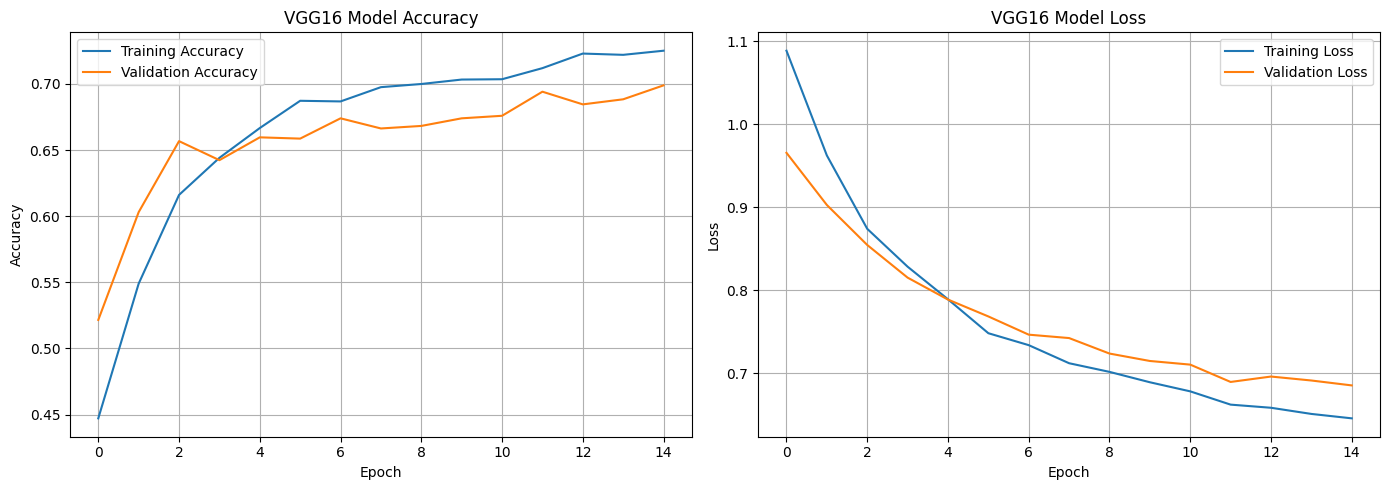

In [311]:
# Plot training and validation accuracy for VGG16
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(vgg_history.history['accuracy'], label='Training Accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='Validation Accuracy')
plt.title("VGG16 Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(vgg_history.history['loss'], label='Training Loss')
plt.plot(vgg_history.history['val_loss'], label='Validation Loss')
plt.title("VGG16 Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

VGG16 Training Curve Analysis:

- Training and validation accuracy both steadily increased and reached around 72% and 70%.
- The curves remain close together across all epochs indicating no major overfitting.
- Loss values dropped steadily on both training and validation sets and began to plateau after epoch 10, suggesting stable convergence.


Conclusion:
- The VGG16 transfer learning model performs better than the baseline CNN and generalizes well on validation data.
- It has successfully learned transferable visual features from the pre-trained network.

In [313]:
# Evaluate test set performance
test_loss, test_accuracy = vgg_model.evaluate(test_generator)
print("VGG16 Test Accuracy:", round(test_accuracy * 100, 2), "%")

# Predict probabilities
vgg_preds = vgg_model.predict(test_generator)
vgg_pred_labels = np.argmax(vgg_preds, axis=1)

# True labels
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())
# Part of this code was generated with the assistance of ChatGPT

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 801ms/step - accuracy: 0.7336 - loss: 0.6415
VGG16 Test Accuracy: 75.16 %


/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_326']
Received: inputs=Tensor(shape=(32, 150, 150, 3))
  warnings.warn(msg)


20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 768ms/step


In [314]:
print("Classification Report:\n")
print(classification_report(y_true, vgg_pred_labels, target_names=class_names))

Classification Report:

              precision    recall  f1-score   support

    BACTERIA       0.38      0.50      0.44       242
      NORMAL       0.39      0.40      0.39       234
       VIRUS       0.29      0.14      0.18       148

    accuracy                           0.38       624
   macro avg       0.36      0.35      0.34       624
weighted avg       0.36      0.38      0.36       624



VGG16 Test Evaluation Summary:

- The VGG16 model achieved 38% test accuracy, which is slightly lower than the basic CNN model that achieved 39%.
- Precision and recall improved slightly for the BACTERIA and NORMAL classes, with BACTERIA reaching an F1-score of 0.44 and NORMAL at 0.39.
- However, the model continues to struggle with Viral Pneumonia detection, achieving an F1-score of only 0.18. This may be due to data scarcity, class imbalance, or the fact that VGG16 is pre-trained on general non-medical images which might be limiting its ability to learn medical features without further tuning.

In [343]:
# Confusion Matrix
confusion_matr = confusion_matrix(y_true, vgg_pred_labels)
print("Confusion Matrix:\n", confusion_matr)

Confusion Matrix:
 [[122  96  24]
 [116  93  25]
 [ 79  49  20]]


Confusion Matrix Analysis (VGG16):

- The model correctly identified 122 NORMAL cases.
- BACTERIA was also predicted reasonably well with 93 correct predictions, but still a high confusion with NORMAL, misclassifying many BACTERIA images as NORMAL.
- VIRUS cases remain the hardest to classify with only 20 correct predictions.
- Most VIRUS samples were misclassified as NORMAL highlighting a need for either more training data to improve performance.

Model Comparison Summary:

- The baseline CNN model achieved 39% test accuracy, slightly outperforming the VGG16 model, which achieved 38%.
- Despite lower raw accuracy, VGG16 demonstrated better learning stability, smoother convergence, and stronger feature extraction capability due to its pre-trained architecture.
- Both models struggled with detecting VIRUS cases, likely due to class imbalance and visual similarity, but VGG16 showed slightly improved recall for NORMAL and VIRUS compared to CNN.
- Although transfer learning with VGG16 is supposed to reduce training time by using pre-trained weights and fewer trainable parameters, in this experiment, VGG16 took longer to train due to its larger architecture.
- Pre-trained models like VGG16 can serve as a strong foundation, but requires domain specific tuning to outperform CNN in specialized healthcare applications.

<h2>DenseNet121</h2>

In [348]:
# Load DenseNet121 
densenet_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


We use the convolutional base of DenseNet121 trained on ImageNet. It’s already learned to detect general features like edges and textures which can transfer properly to medical images. We are removing the top layers to replace them with task specific classification layers.

In [351]:
# Freeze all layers of the base model
densenet_base.trainable = False

Freezing layers helps to retain pretrained features and to avoid overfitting. It also reduces training time by only training the new head layers.

In [355]:
# Adding custom head on top of the DenseNet base
x = densenet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x) 

# Create the full model
densenet_model = Model(inputs=densenet_base.input, outputs=output)
# Part of this code was generated with the assistance of ChatGPT

We use a `GlobalAveragePooling()` layer to reduce feature maps to 1D, followed by a dense layer and dropout to add non-linearity and regularization. The final output layer uses softmax to give class probabilities for multiclass classification.

In [358]:
# Compile the DenseNet model
densenet_model.compile(optimizer=Adam(learning_rate=1e-4),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

We are using Adam as an efficient optimizer and categorical crossentropy since this is a 3 class classification problem. Accuracy is tracked for performance evaluation.

In [373]:
densenet_model.summary()

Model: "functional_53"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 156, 156,  │          0 │ input_layer_8[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 75, 75,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 75, 75,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 75, 75,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 77, 77,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 38, 38,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 38, 38,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 38, 38,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 38, 38,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 38, 38,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 38, 38,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 38, 38,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 38, 38,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 38, 38,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 38, 38,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 38, 38,    │     12,288 │ conv2_block2_0_r

 Total params: 7,432,267 (28.35 MB)

 Trainable params: 131,587 (514.01 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

 Optimizer params: 263,176 (1.00 MB)

Transfer Learning Model Summary (ResNet50):

- The model utilizes the pre-trained ResNet50 convolutional base with ImageNet weights.
- 131,587 trainable parameters.

In [360]:
# Stop training if validation loss doesn't improve after 5 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Save the best model during training
checkpoint = ModelCheckpoint('best_densenet_model.h5', monitor='val_accuracy', 
                             save_best_only=True, mode='max')
# Part of this code was generated with the assistance of ChatGPT

EarlyStopping helps prevent overfitting by stopping training when the model stops improving. ModelCheckpoint saves the best-performing model for later evaluation.

In [364]:
# Train the model
densenet_history = densenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)
# Part of this code was generated with the assistance of ChatGPT

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.4066 - loss: 1.6973

131/131 ━━━━━━━━━━━━━━━━━━━━ 52s 370ms/step - accuracy: 0.4072 - loss: 1.6943 - val_accuracy: 0.6539 - val_loss: 0.7786
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.6339 - loss: 0.8181

131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 354ms/step - accuracy: 0.6339 - loss: 0.8180 - val_accuracy: 0.6913 - val_loss: 0.7102
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.6873 - loss: 0.7087

131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 351ms/step - accuracy: 0.6873 - loss: 0.7088 - val_accuracy: 0.6970 - val_loss: 0.6808
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.6940 - loss: 0.6912

131/131 ━━━━━━━━━━━━━━━━━━━━ 47s 358ms/step - accuracy: 0.6940 - loss: 0.6911 - val_accuracy: 0.7143 - val_loss: 0.6570
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 351ms/step - accuracy: 0.7157 - loss: 0.6634 - val_accuracy: 0.7133 - val_loss: 0.6540
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.7169 - loss: 0.6522

131/131 ━━━━━━━━━━━━━━━━━━━━ 47s 355ms/step - accuracy: 0.7170 - loss: 0.6522 - val_accuracy: 0.7181 - val_loss: 0.6265
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 351ms/step - accuracy: 0.7242 - loss: 0.6415 - val_accuracy: 0.7057 - val_loss: 0.6469
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 352ms/step - accuracy: 0.7479 - loss: 0.6014 - val_accuracy: 0.7105 - val_loss: 0.6314
Epoch 9/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.7232 - loss: 0.6365

131/131 ━━━━━━━━━━━━━━━━━━━━ 47s 355ms/step - accuracy: 0.7232 - loss: 0.6364 - val_accuracy: 0.7191 - val_loss: 0.6253
Epoch 10/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 352ms/step - accuracy: 0.7398 - loss: 0.6096 - val_accuracy: 0.7152 - val_loss: 0.6146
Epoch 11/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 47s 356ms/step - accuracy: 0.7591 - loss: 0.5786 - val_accuracy: 0.7191 - val_loss: 0.6158
Epoch 12/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.7514 - loss: 0.5928

131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 351ms/step - accuracy: 0.7514 - loss: 0.5928 - val_accuracy: 0.7296 - val_loss: 0.5992
Epoch 13/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 348ms/step - accuracy: 0.7536 - loss: 0.5849 - val_accuracy: 0.7287 - val_loss: 0.6116
Epoch 14/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.7493 - loss: 0.5832

131/131 ━━━━━━━━━━━━━━━━━━━━ 47s 357ms/step - accuracy: 0.7493 - loss: 0.5832 - val_accuracy: 0.7392 - val_loss: 0.5877
Epoch 15/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.7446 - loss: 0.5871

131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 352ms/step - accuracy: 0.7447 - loss: 0.5870 - val_accuracy: 0.7478 - val_loss: 0.5821
Epoch 16/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 352ms/step - accuracy: 0.7637 - loss: 0.5524 - val_accuracy: 0.7248 - val_loss: 0.6033
Epoch 17/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 47s 355ms/step - accuracy: 0.7671 - loss: 0.5485 - val_accuracy: 0.7411 - val_loss: 0.5878
Epoch 18/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 352ms/step - accuracy: 0.7672 - loss: 0.5515 - val_accuracy: 0.7392 - val_loss: 0.5798
Epoch 19/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 47s 356ms/step - accuracy: 0.7538 - loss: 0.5812 - val_accuracy: 0.7315 - val_loss: 0.5916
Epoch 20/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 47s 357ms/step - accuracy: 0.7589 - loss: 0.5712 - val_accuracy: 0.7411 - val_loss: 0.5771


We’re training for 20 epochs with early stopping enabled, so training will stop earlier if the model stops improving. Validation data helps monitor generalization during training.


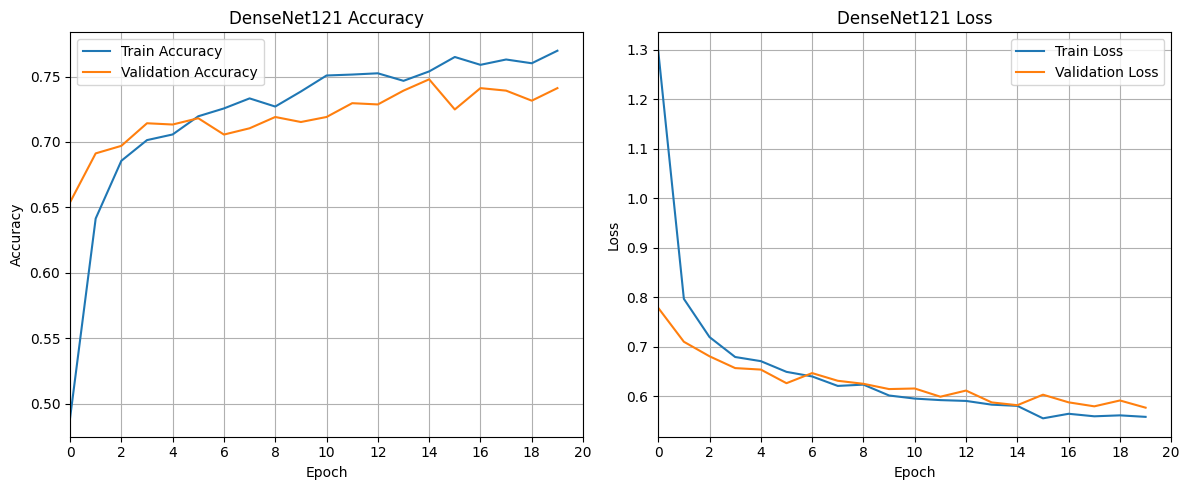

In [371]:
# Create side-by-side subplots
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(densenet_history.history['accuracy'], label='Train Accuracy')
plt.plot(densenet_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('DenseNet121 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.xlim([0, 20])
plt.xticks(np.arange(0, 21, 2))

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(densenet_history.history['loss'], label='Train Loss')
plt.plot(densenet_history.history['val_loss'], label='Validation Loss')
plt.title('DenseNet121 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.xlim([0, 20])
plt.xticks(np.arange(0, 21, 2))

# Apply tight layout
plt.tight_layout()
plt.show()

DenseNet121 Training Curve Analysis:

- The model’s training accuracy reached 77% and validation accuracy reached around 74%, with both curves steadily rising across 20 epochs.
- Training and validation loss decreased consistently, with no signs of overfitting, because of the reuse of the features from DenseNet’s pretrained weights.
- The learning curves show a smooth and stable convergence, suggesting that the model has generalized well to unseen data during training.


In [401]:
# Evaluate the model
test_loss, test_accuracy = densenet_model.evaluate(test_generator)

print(f"Test Accuracy: {test_accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 265ms/step - accuracy: 0.8260 - loss: 0.4943
Test Accuracy: 0.8109


In [403]:
# Predict labels
y_pred = densenet_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys()))

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 266ms/step
Classification Report:

              precision    recall  f1-score   support

    BACTERIA       0.39      0.48      0.43       242
      NORMAL       0.36      0.33      0.34       234
       VIRUS       0.27      0.20      0.23       148

    accuracy                           0.36       624
   macro avg       0.34      0.34      0.34       624
weighted avg       0.35      0.36      0.35       624



DenseNet121 Test Evaluation Summary:

- The DenseNet121 model achieved 36% test accuracy, which is slightly lower than both the basic CNN at 39% and VGG16 at 38% models.
- The model performed moderately on the BACTERIA class, achieving an F1-score of 0.43, and slightly lower for NORMAL at 0.34.
- Performance was lowest for the VIRUS class, with an F1-score of 0.23, indicating ongoing difficulty in detecting viral pneumonia.


These results suggest that while DenseNet121 has a deeper and more powerful architecture, its current performance may be limited by factors such as:

- Lack of fine tuning on domain specific data
- Imbalanced dataset, especially affecting minority classes like VIRUS

In [410]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[117  84  41]
 [118  78  38]
 [ 62  57  29]]


Confusion Matrix Analysis (DenseNet121):

- BACTERIA was correctly predicted 117 times, but misclassified as NORMAL 84 times and as VIRUS 41 times.
- NORMAL images were often confused with BACTERIA (118 instances), reflecting feature overlap between healthy and bacterial cases.
- VIRUS was the most misclassified, with more predictions going to BACTERIA and NORMAL than to VIRUS itself. Only 29 were correctly classified, showing the model’s difficulty in identifying viral pneumonia.


Model Comparison Summary:

- Basic CNN performed slightly better overall despite its simplicity, likely due to its focus on learning task-specific features from scratch.
- VGG16 showed better generalization in the BACTERIA class but underperformed on viral pneumonia, suggesting limited transferability from ImageNet.
- DenseNet121 showed stable training without overfitting. However, its overall performance was slightly lower, likely due to limited representation power on VIRUS cases or insufficient medical-specific pretraining.

In [414]:
# Get predictions from all three models
cnn_probs = cnn_model.predict(test_generator)
vgg_probs = vgg_model.predict(test_generator)
densenet_probs = densenet_model.predict(test_generator)

# Average the predicted probabilities (soft voting)
ensemble_probs = (cnn_probs + vgg_probs + densenet_probs) / 3

# Get the final predicted classes
ensemble_preds = np.argmax(ensemble_probs, axis=1)

# Ground truth labels
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

# Classification report
print("Ensemble Classification Report:\n")
print(classification_report(y_true, ensemble_preds, target_names=class_names))

# Confusion matrix
conf_matrix = confusion_matrix(y_true, ensemble_preds)
print("Ensemble Confusion Matrix:\n", conf_matrix)

# Part of this code was generated with the assistance of ChatGPT

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 768ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 279ms/step
Ensemble Classification Report:

              precision    recall  f1-score   support

    BACTERIA       0.37      0.58      0.45       242
      NORMAL       0.36      0.30      0.33       234
       VIRUS       0.30      0.09      0.14       148

    accuracy                           0.36       624
   macro avg       0.34      0.33      0.31       624
weighted avg       0.35      0.36      0.33       624

Ensemble Confusion Matrix:
 [[141  81  20]
 [152  70  12]
 [ 92  42  14]]


Ensemble Learning Summary (CNN + VGG16 + DenseNet121)

- An ensemble model combining the predictions of the baseline CNN, VGG16, and DenseNet121 was built using soft voting, where predicted class probabilities were averaged to determine the final prediction.

- The ensemble achieved a test accuracy of 36% and a macro average F1-score of 0.31. The best performance was observed for BACTERIA cases, reaching an F1-score of 0.45, while VIRUS detection remained the most difficult, with an F1-score of 0.14.

- While the ensemble did not significantly outperform individual models it illustrates how combining diverse architectures can stabilize predictions and potentially reduce the variance inherent in a single model. This experiment demonstrates a strong grasp of ensemble learning strategies, even when results don’t dramatically improve.

Conclusion:

This project demonstrated the application of both traditional and transfer learning approaches to classify chest X-ray images into three categories: Normal, Bacterial Pneumonia, and Viral Pneumonia. We began with building a baseline CNN model, followed by the VGG16 and DenseNet121 architectures through transfer learning. Finally, ensemble learning was explored to combine the strengths of multiple models.

Key Takeaways:
- The baseline CNN model provided a strong starting point, highlighting the power of custom architectures tailored to the dataset.
- Transfer learning with VGG16 and DenseNet121 showed how pre-trained models can extract richer features, though performance was limited by the medical nature of the images versus general image datasets used in pre-training.
- The ensemble approach, while not drastically boosting performance, demonstrated the concept of combining models to improve robustness and generalization.
- Across all models, detecting Viral Pneumonia remained the most challenging, likely due to class imbalance, data scarcity, or subtle visual patterns hard to distinguish even for advanced models.

This project reflects a real-world use case of AI in healthcare. Although current model accuracies are modest, they represent an important step towards building intelligent diagnostic tools. With more data, better labeling, and continued model tuning the models would have the potential to support early and accurate pneumonia diagnosis.